In [46]:
# import needed libraries

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


#### 1. Read the car dataset

In [47]:
# read the clean data
df=pd.read_csv("../data/car_data.csv")

In [48]:
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


#### 2. Subset the price and fuel consumption related information  

In [49]:
# Create a new dataframe with fuel consumption and price columns
df_num=df[['highway MPG', 'city mpg', 'MSRP']]

In [50]:
df_num

,highway MPG,city mpg,MSRP
0,26,19,46135
1,28,19,40650
2,28,20,36350
3,28,18,29450
4,28,18,34500
...,...,...,...
11909,23,16,46120
11910,23,16,56670
11911,23,16,50620
11912,23,16,50920


In [51]:
df_num.describe()

,highway MPG,city mpg,MSRP
count,11914.000000,11914.000000,1.191400e+04
mean,26.637485,19.733255,4.059474e+04
std,8.863001,8.987798,6.010910e+04
min,12.000000,7.000000,2.000000e+03
25%,22.000000,16.000000,2.100000e+04
50%,26.000000,18.000000,2.999500e+04
75%,30.000000,22.000000,4.223125e+04
max,354.000000,137.000000,2.065902e+06


In [52]:
df_num.isnull().sum()

highway MPG    0
city mpg       0
MSRP           0
dtype: int64

#### 3. Check the distribution of data and standardize it if necessary

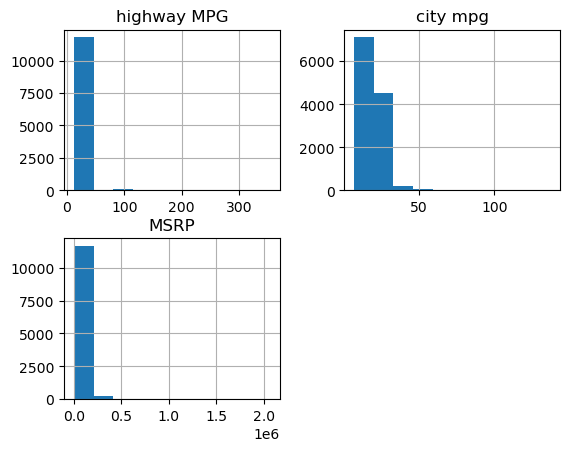

In [53]:
# Check the data distribution
df_num.hist();

In [54]:
# Standardize the data
scaler = StandardScaler()
scaler.fit(df_num)
df_num_scaled = scaler.transform(df_num)
df_num_scaled


array([[-0.0719296 , -0.08158681,  0.09217398],
       [ 0.15373708, -0.08158681,  0.00091942],
       [ 0.15373708,  0.02967982, -0.07062017],
       ...,
       [-0.41042961, -0.41538668,  0.16679144],
       [-0.41042961, -0.41538668,  0.17178257],
       [-0.0719296 , -0.30412006, -0.19298614]])

In [55]:
# Make a dataframe from the scaled data
df_fuel_price = pd.DataFrame(df_num_scaled, columns=df_num.columns)
df_fuel_price.head()

,highway MPG,city mpg,MSRP
0,-0.071930,-0.081587,0.092174
1,0.153737,-0.081587,0.000919
2,0.153737,0.029680,-0.070620
3,0.153737,-0.192853,-0.185416
4,0.153737,-0.192853,-0.101399


In [56]:
df_fuel_price.describe()

,highway MPG,city mpg,MSRP
count,1.191400e+04,1.191400e+04,1.191400e+04
mean,8.588061e-17,-1.813035e-16,5.248259e-17
std,1.000042e+00,1.000042e+00,1.000042e+00
min,-1.651596e+00,-1.416786e+00,-6.421050e-01
25%,-5.232630e-01,-4.153867e-01,-3.259999e-01
50%,-7.192960e-02,-1.928534e-01,-1.763490e-01
75%,3.794038e-01,2.522131e-01,2.722685e-02
max,3.693741e+01,1.304787e+01,3.369527e+01


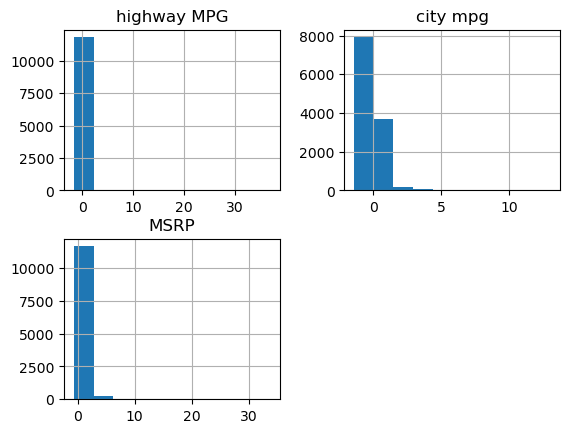

In [57]:
df_fuel_price.hist();

#### 4. Use the elbow method to determine the number of clusters

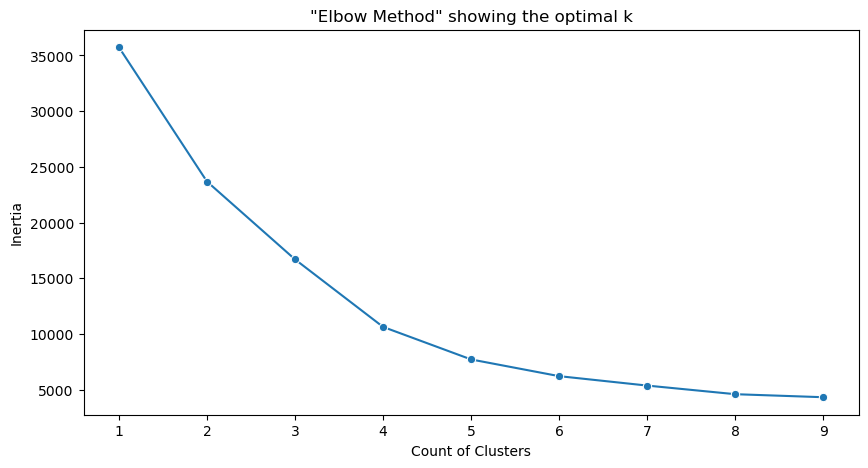

In [58]:
# Use the code from the encounter and adapt it to implement the elbow method
# K = range(1, 10) 

K = range(1, 10) #let's give it a range
inertia_list = []

for k in K:
    kmeans = KMeans(n_clusters=k,
                    random_state=1234) # a different random state
    kmeans.fit(df_fuel_price)
    inertia_list.append(kmeans.inertia_) 

# Generate the x-axis values (1, 2, 3, ...)
x = list(range(1, len(inertia_list) + 1))

# Create a Seaborn line plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=x, y=inertia_list, marker='o')

# Add labels and title
plt.xlabel('Count of Clusters')
plt.ylabel('Inertia')
plt.title('"Elbow Method" showing the optimal k')

# Remove the grid
plt.grid(False)

# Display the plot
plt.show()


We can see a light elbow for k = 4 which fits our knowledge of the dataset.

In [59]:
# Since we are not sure about how many clusters we should have, 
# we may need to generate the same labels again and again. Therefore using 'random state' is a good idea

kmeans = KMeans(n_clusters=5, #The number of clusters to form as well as the number of centroids to generate.
                random_state=42) #Determines random number generation for centroid initialization.
kmeans.fit(df_fuel_price)

KMeans(n_clusters=5, random_state=42)

In [60]:
# retrieve array of cluster labels from our kmeans model
clusters = kmeans.labels_
clusters

array([1, 1, 1, ..., 0, 0, 1], dtype=int32)

In [61]:
# retrieve unique clusters
labels = np.unique(clusters)
labels

array([0, 1, 2, 3, 4], dtype=int32)

In [62]:
#How many penguins in which cluster?
#clusters = kmeans.predict(df_penguins)

pd.Series(clusters).value_counts().sort_index()

0    4906
1    4666
2     380
3      67
4    1895
dtype: int64

In [63]:
df_clustered = df_fuel_price.copy() 
df_clustered["cluster"] = clusters
df_clustered

,highway MPG,city mpg,MSRP,cluster
0,-0.071930,-0.081587,0.092174,1
1,0.153737,-0.081587,0.000919,1
2,0.153737,0.029680,-0.070620,1
3,0.153737,-0.192853,-0.185416,1
4,0.153737,-0.192853,-0.101399,1
...,...,...,...,...
11909,-0.410430,-0.415387,0.091924,0
11910,-0.410430,-0.415387,0.267446,0
11911,-0.410430,-0.415387,0.166791,0
11912,-0.410430,-0.415387,0.171783,0


In [64]:
df_clustered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   highway MPG  11914 non-null  float64
 1   city mpg     11914 non-null  float64
 2   MSRP         11914 non-null  float64
 3   cluster      11914 non-null  int32  
dtypes: float64(3), int32(1)
memory usage: 325.9 KB


In [65]:
df['cluster']=df_clustered['cluster'] 
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,1
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,1
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,1
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,1
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,0
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,0
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,0
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920,0


In [108]:
df['cluster'].apply(type)

0        <class 'int'>
1        <class 'int'>
2        <class 'int'>
3        <class 'int'>
4        <class 'int'>
             ...      
11909    <class 'int'>
11910    <class 'int'>
11911    <class 'int'>
11912    <class 'int'>
11913    <class 'int'>
Name: cluster, Length: 11914, dtype: object

In [66]:
cluster_0 = df.loc[df['cluster'] == 0]
cluster_0

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
19,Audi,100,1992,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Wagon,20,16,3105,2000,0
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
21,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Luxury,Midsize,Sedan,21,16,3105,2000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2011,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50520,0
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,0
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,0
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,0


In [67]:
cluster_1 = df.loc[df['cluster'] == 1]
cluster_1

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,1
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,1
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,1
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,1
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11894,BMW,Z4,2014,premium unleaded (required),240.0,4.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,34,22,3916,48950,1
11895,BMW,Z4,2014,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Convertible,26,19,3916,56950,1
11897,BMW,Z4,2015,premium unleaded (required),240.0,4.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,34,22,3916,48950,1
11901,BMW,Z4,2016,premium unleaded (required),240.0,4.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,34,22,3916,49700,1


In [68]:
cluster_2 = df.loc[df['cluster'] == 2]
cluster_2

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
294,Ferrari,360,2002,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,160829,2
297,Ferrari,360,2002,premium unleaded (required),400.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,170829,2
298,Ferrari,360,2003,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,165986,2
301,Ferrari,360,2003,premium unleaded (required),400.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,176287,2
302,Ferrari,360,2004,premium unleaded (required),400.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,15,10,2774,157767,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11394,Aston Martin,Virage,2012,premium unleaded (required),490.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,High-Performance",Midsize,Coupe,18,13,259,208295,2
11395,Aston Martin,Virage,2012,premium unleaded (required),490.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,High-Performance",Midsize,Convertible,18,13,259,223295,2
11448,Rolls-Royce,Wraith,2014,premium unleaded (required),624.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,Luxury,High-Performance",Large,Coupe,21,13,86,284900,2
11449,Rolls-Royce,Wraith,2015,premium unleaded (required),624.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,Luxury,High-Performance",Large,Coupe,21,13,86,294025,2


In [69]:
cluster_3 = df.loc[df['cluster'] == 3]
cluster_3

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
539,FIAT,500e,2015,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,108,122,819,31800,3
540,FIAT,500e,2016,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,103,121,819,31800,3
541,FIAT,500e,2017,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,103,121,819,31800,3
1119,Audi,A6,2017,premium unleaded (recommended),252.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,354,24,3105,51600,3
1680,Mercedes-Benz,B-Class Electric Drive,2015,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,82,85,617,41450,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9868,Chevrolet,Spark EV,2014,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,109,128,1385,27010,3
9869,Chevrolet,Spark EV,2015,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,109,128,1385,25170,3
9870,Chevrolet,Spark EV,2015,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,109,128,1385,25560,3
9871,Chevrolet,Spark EV,2016,electric,140.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,109,128,1385,25510,3


In [70]:
cluster_4 = df.loc[df['cluster'] == 4]
cluster_4

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
32,FIAT,124 Spider,2017,premium unleaded (recommended),160.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,35,26,819,27495,4
33,FIAT,124 Spider,2017,premium unleaded (recommended),160.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,35,26,819,24995,4
34,FIAT,124 Spider,2017,premium unleaded (recommended),160.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,35,26,819,28195,4
41,BMW,2 Series,2016,premium unleaded (required),240.0,4.0,AUTOMATIC,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,35,23,3916,32850,4
42,BMW,2 Series,2016,premium unleaded (required),240.0,4.0,AUTOMATIC,rear wheel drive,2.0,Luxury,Compact,Convertible,34,23,3916,38650,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11827,Toyota,Yaris,2017,regular unleaded,106.0,4.0,MANUAL,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,36,30,2031,15250,4
11828,Toyota,Yaris,2017,regular unleaded,106.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,35,30,2031,16375,4
11829,Toyota,Yaris,2017,regular unleaded,106.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,35,30,2031,17285,4
11830,Toyota,Yaris,2017,regular unleaded,106.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,35,30,2031,18000,4


<Axes: xlabel='highway MPG', ylabel='MSRP'>

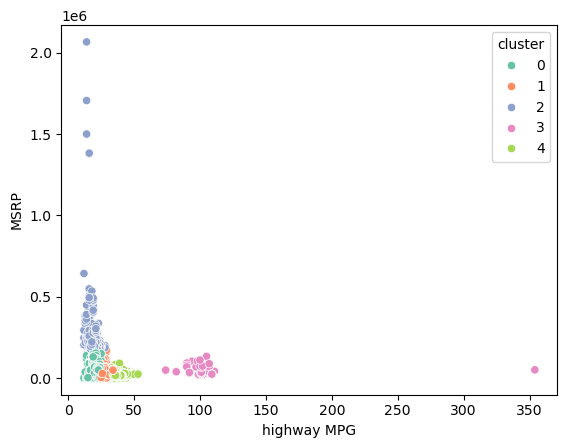

In [105]:
sns.scatterplot(data= df,x="highway MPG", y= "MSRP", hue="cluster", palette='Set2')

<Axes: xlabel='city mpg', ylabel='MSRP'>

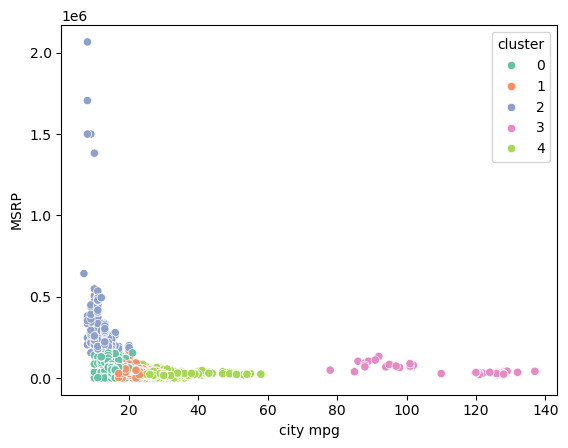

In [106]:
sns.scatterplot(data= df,x="city mpg", y= "MSRP", hue="cluster", palette='Set2')

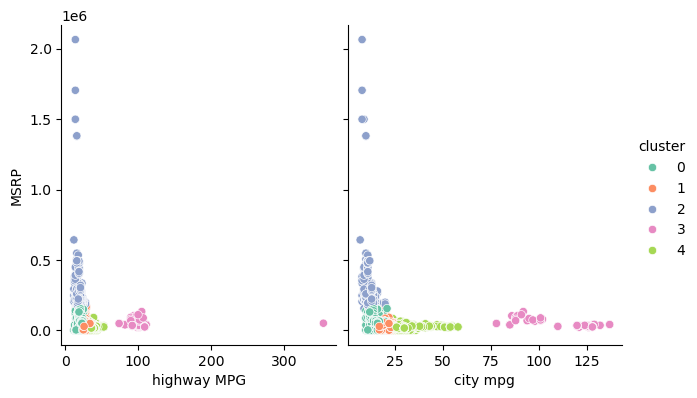

In [107]:
# Pairplot
sns.pairplot(df, x_vars=['highway MPG','city mpg'], y_vars='MSRP', height=4, aspect=0.8, hue='cluster', palette='Set2')
plt.show()

#### 5. Repeat k-means clustering using the appropriate number of clusters selected from the elbow method. Visualize the results with a scatter plot.

In [73]:
# Since we are not sure about how many clusters we should have, 
# we may need to generate the same labels again and again. Therefore using 'random state' is a good idea

kmeans = KMeans(n_clusters=4, #The number of clusters to form as well as the number of centroids to generate.
                random_state=42) #Determines random number generation for centroid initialization.
kmeans.fit(df_fuel_price)

KMeans(n_clusters=4, random_state=42)

In [74]:
# retrieve array of cluster labels from our kmeans model
clusters_alternative = kmeans.labels_
clusters_alternative

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [75]:
# retrieve unique clusters
labels_alternative = np.unique(clusters_alternative)
labels_alternative

array([0, 1, 2, 3], dtype=int32)

In [76]:
#How many penguins in which cluster?
#clusters = kmeans.predict(df_penguins)

pd.Series(clusters_alternative).value_counts().sort_index()

0    7356
1    4105
2     386
3      67
dtype: int64

In [77]:
df_clustered_alternative = df_fuel_price.copy() 
df_clustered_alternative["cluster"] = clusters_alternative
df_clustered_alternative

,highway MPG,city mpg,MSRP,cluster
0,-0.071930,-0.081587,0.092174,0
1,0.153737,-0.081587,0.000919,0
2,0.153737,0.029680,-0.070620,0
3,0.153737,-0.192853,-0.185416,0
4,0.153737,-0.192853,-0.101399,0
...,...,...,...,...
11909,-0.410430,-0.415387,0.091924,0
11910,-0.410430,-0.415387,0.267446,0
11911,-0.410430,-0.415387,0.166791,0
11912,-0.410430,-0.415387,0.171783,0


In [78]:
df_clustered_alternative.describe()

,highway MPG,city mpg,MSRP,cluster
count,1.191400e+04,1.191400e+04,1.191400e+04,11914.000000
mean,8.588061e-17,-1.813035e-16,5.248259e-17,0.426221
std,1.000042e+00,1.000042e+00,1.000042e+00,0.585769
min,-1.651596e+00,-1.416786e+00,-6.421050e-01,0.000000
25%,-5.232630e-01,-4.153867e-01,-3.259999e-01,0.000000
50%,-7.192960e-02,-1.928534e-01,-1.763490e-01,0.000000
75%,3.794038e-01,2.522131e-01,2.722685e-02,1.000000
max,3.693741e+01,1.304787e+01,3.369527e+01,3.000000


In [79]:
df_alternative=df.copy().drop('cluster', axis=1)
df_alternative

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [80]:
df_alternative['cluster']=df_clustered_alternative['cluster'] 
df_alternative

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,0
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,0
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,0
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,0
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,0
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,0
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,0
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920,0


In [81]:
cluster_0_alternative= df.loc[df['cluster'] == 0]
cluster_0_alternative

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
19,Audi,100,1992,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Wagon,20,16,3105,2000,0
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
21,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Luxury,Midsize,Sedan,21,16,3105,2000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2011,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50520,0
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,0
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,0
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,0


In [82]:
cluster_1_alternative= df.loc[df['cluster'] == 1]
cluster_1_alternative

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,1
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,1
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,1
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,1
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11894,BMW,Z4,2014,premium unleaded (required),240.0,4.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,34,22,3916,48950,1
11895,BMW,Z4,2014,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Convertible,26,19,3916,56950,1
11897,BMW,Z4,2015,premium unleaded (required),240.0,4.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,34,22,3916,48950,1
11901,BMW,Z4,2016,premium unleaded (required),240.0,4.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,34,22,3916,49700,1


In [83]:
cluster_2_alternative= df.loc[df['cluster'] == 2]
cluster_2_alternative

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
294,Ferrari,360,2002,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,160829,2
297,Ferrari,360,2002,premium unleaded (required),400.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,170829,2
298,Ferrari,360,2003,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,165986,2
301,Ferrari,360,2003,premium unleaded (required),400.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,176287,2
302,Ferrari,360,2004,premium unleaded (required),400.0,8.0,AUTOMATED_MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,15,10,2774,157767,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11394,Aston Martin,Virage,2012,premium unleaded (required),490.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,High-Performance",Midsize,Coupe,18,13,259,208295,2
11395,Aston Martin,Virage,2012,premium unleaded (required),490.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,High-Performance",Midsize,Convertible,18,13,259,223295,2
11448,Rolls-Royce,Wraith,2014,premium unleaded (required),624.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,Luxury,High-Performance",Large,Coupe,21,13,86,284900,2
11449,Rolls-Royce,Wraith,2015,premium unleaded (required),624.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,Luxury,High-Performance",Large,Coupe,21,13,86,294025,2


In [84]:
cluster_3_alternative= df.loc[df['cluster'] == 0]
cluster_3_alternative

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,cluster
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
19,Audi,100,1992,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Wagon,20,16,3105,2000,0
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000,0
21,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Luxury,Midsize,Sedan,21,16,3105,2000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2011,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50520,0
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,0
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,0
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,0


<Axes: xlabel='highway MPG', ylabel='MSRP'>

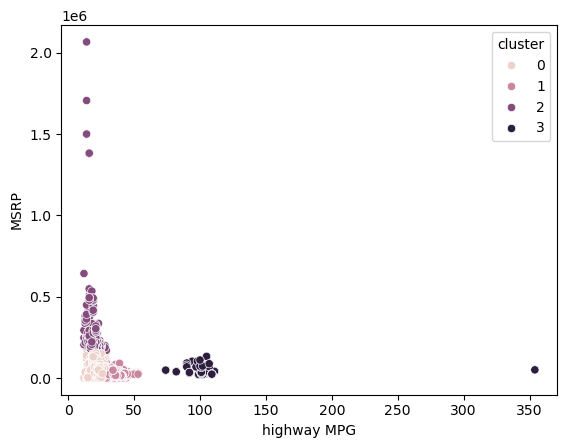

In [85]:
sns.scatterplot(data= df_alternative,x="highway MPG", y= "MSRP", hue="cluster")

<Axes: xlabel='city mpg', ylabel='MSRP'>

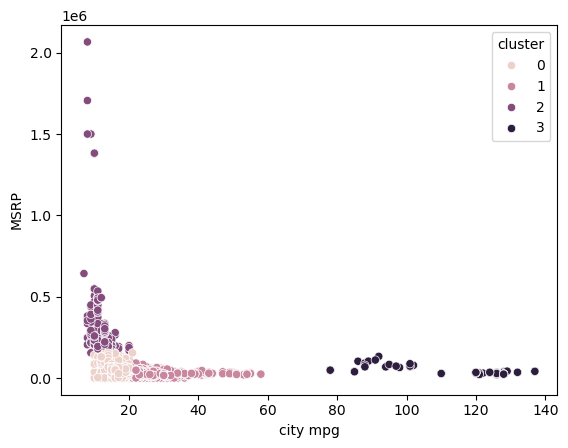

In [86]:
sns.scatterplot(data= df_alternative,x="city mpg", y= "MSRP", hue="cluster")

In [91]:
df_fuel_price

,highway MPG,city mpg,MSRP
0,-0.071930,-0.081587,0.092174
1,0.153737,-0.081587,0.000919
2,0.153737,0.029680,-0.070620
3,0.153737,-0.192853,-0.185416
4,0.153737,-0.192853,-0.101399
...,...,...,...
11909,-0.410430,-0.415387,0.091924
11910,-0.410430,-0.415387,0.267446
11911,-0.410430,-0.415387,0.166791
11912,-0.410430,-0.415387,0.171783


In [95]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_fuel_price)

clusters_alternative_1 = kmeans.labels_
df_clustered_alternative_1= df_fuel_price.copy() 
df_clustered_alternative_1["cluster"] = clusters_alternative_1
df_clustered_alternative_1

,highway MPG,city mpg,MSRP,cluster
0,-0.071930,-0.081587,0.092174,0
1,0.153737,-0.081587,0.000919,0
2,0.153737,0.029680,-0.070620,0
3,0.153737,-0.192853,-0.185416,0
4,0.153737,-0.192853,-0.101399,0
...,...,...,...,...
11909,-0.410430,-0.415387,0.091924,0
11910,-0.410430,-0.415387,0.267446,0
11911,-0.410430,-0.415387,0.166791,0
11912,-0.410430,-0.415387,0.171783,0


<Axes: xlabel='highway MPG', ylabel='MSRP'>

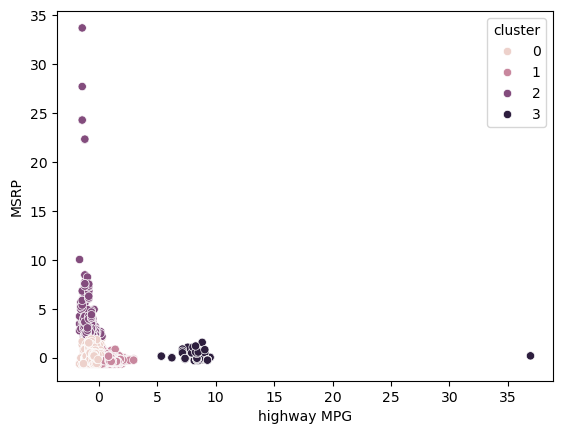

In [96]:
sns.scatterplot(data= df_clustered_alternative_1,x="highway MPG", y= "MSRP", hue="cluster")

<Axes: xlabel='city mpg', ylabel='MSRP'>

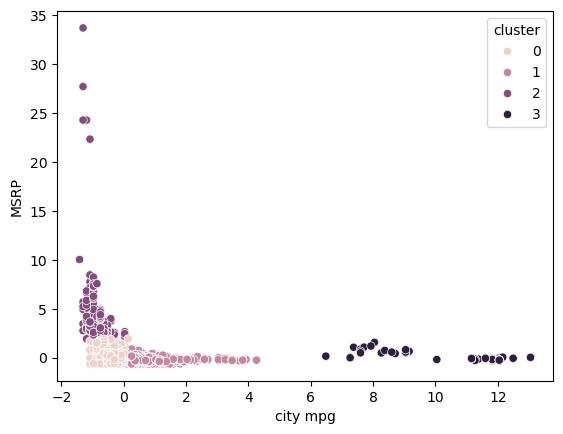

In [97]:
sns.scatterplot(data= df_clustered_alternative_1,x="city mpg", y= "MSRP", hue="cluster")

#### 6. What information can you provide regarding the various clusters?